# FEEMS: *An. farauti* s.s. — Australia + Torres Strait / southern PNG

**Kernel**: `feems_e` — installed at `/scratch/user/uqtdenni/.conda/envs/feems_e`, registered as a Jupyter kernel. Packages: Novembre Lab feems (GitHub), pandas-plink, scikit-learn, statsmodels, cartopy, scikit-sparse (requires SuiteSparse via conda).

**Data**:
- BED/BIM/FAM: `farauti_complex_evolution/data/admixture_input/farauti_ss_AUS_TSIsNG.*` (138 samples, LD-thinned)
- Metadata: `farauti_complex_evolution/metadata/metadata-cleaned-20260312.csv`
- Grid: `scripts/dgg_triangle_res_06.shp` (ISEA4T resolution 6, bbox 127–151°E, 6–23°S)
- Coastline outline: `scripts/AUS_PNG_outline.csv` — NE 10m land clipped to bbox, dissolved with 0.6° buffer to bridge Torres Strait, simplified to 99 vertices (all 138 samples confirmed inside polygon)

**Known data issue**:
- **Swapped coordinate** — `far_NT163-2` has lat/lon swapped in the metadata (lat=130.073, lon=−11.684). Fixed in cell 3 below; verify against the original field records.

In [1]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from pandas_plink import read_plink

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from feems.utils import prepare_graph_inputs
from feems.cross_validation import run_cv
from feems import SpatialGraph, Viz

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.sans-serif"] = "Arial"

## 1. Load genotype data

In [2]:
bed_path = "/scratch/user/uqtdenni/farauti_complex_evolution/data/admixture_input/farauti_ss_AUS_TSIsNG"

(bim, fam, G) = read_plink(bed_path)
imp = SimpleImputer(missing_values=np.nan, strategy="mean")
genotypes = imp.fit_transform(np.array(G).T)
print("n_samples={}, n_snps={}".format(genotypes.shape[0], genotypes.shape[1]))

Mapping files:   0%|          | 0/3 [00:00<?, ?it/s]/scratch/user/uqtdenni/.conda/envs/feems_e/lib/python3.12/site-packages/pandas_plink/_read.py:338: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = read_csv(
/scratch/user/uqtdenni/.conda/envs/feems_e/lib/python3.12/site-packages/pandas_plink/_read.py:338: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = read_csv(
Mapping files: 100%|██████████| 3/3 [00:00<00:00, 36.12it/s]


n_samples=138, n_snps=100000


## 2. Load metadata and align coordinates to FAM order

FEEMS requires that rows in `genotypes` and rows in `coord` are in the same order.
We merge on the IID column from the FAM file to guarantee this.

In [3]:
meta = pd.read_csv(
    "/scratch/user/uqtdenni/farauti_complex_evolution/metadata/metadata-cleaned-20260312.csv"
)

# Merge in FAM row order so genotype rows stay aligned with coordinates
df_samples = fam[["iid"]].merge(
    meta[["sample_id", "latitude", "longitude", "site", "country"]],
    left_on="iid",
    right_on="sample_id",
    how="left",
)
assert len(df_samples) == genotypes.shape[0], "sample count mismatch after merge"

# Fix swapped lat/lon for far_NT163-2
# Metadata has lat=130.073, lon=-11.684 — clearly transposed for an NT Australia site
mask = df_samples["sample_id"] == "far_NT163-2"
df_samples.loc[mask, ["latitude", "longitude"]] = (
    df_samples.loc[mask, ["longitude", "latitude"]].values
)

print("Samples with coords:", df_samples[["latitude", "longitude"]].notna().all(axis=1).sum())
print(df_samples[["sample_id", "latitude", "longitude", "country"]].head(10))

Samples with coords: 138
        sample_id  latitude  longitude    country
0     far_NT-PC35   -12.493    130.955  Australia
1     far_NT-cas3   -12.355    130.871  Australia
2     far_NT-cas8   -12.355    130.871  Australia
3     far_NT103-4   -12.067    134.567  Australia
4     far_NT163-2   -11.684    130.073  Australia
5    far_NT1680-1   -11.683    130.067  Australia
6    far_NT1680-3   -11.683    130.067  Australia
7    far_NT2124-2   -13.150    130.119  Australia
8       far_NT4-1   -12.067    134.567  Australia
9  far_NT_NT103-2   -12.067    134.567  Australia


## 3. Filter to segregating SNPs and handle missing coordinates

In [4]:
# Drop any samples missing coordinates (none expected, but defensive)
miss_bool = df_samples[["latitude", "longitude"]].isna().any(axis=1).values
if miss_bool.sum() > 0:
    print(f"Dropping {miss_bool.sum()} samples with missing coordinates")
    genotypes = genotypes[~miss_bool]
    df_samples = df_samples[~miss_bool].reset_index(drop=True)

# FEEMS requires [longitude, latitude] order
coord = df_samples[["longitude", "latitude"]].to_numpy()

# Keep only segregating SNPs
seg_bool = (genotypes.sum(axis=0) > 0) & (genotypes.sum(axis=0) < genotypes.shape[0] * 2)
genotypes = genotypes[:, seg_bool]
print("After seg-site filter: n_samples={}, n_snps={}".format(genotypes.shape[0], genotypes.shape[1]))

After seg-site filter: n_samples=138, n_snps=12394


## 4. Build spatial graph

The grid `dgg_triangle_res_06.shp` was generated by `scripts/generate-grid.R` using an ISEA4T resolution-6 triangular grid over the bbox 127–151°E, 6–23°S.

The outer boundary `AUS_PNG_outline.csv` was derived from Natural Earth 10m land, clipped to the study bbox, with land polygons dissolved and a 0.6° buffer applied to bridge the Torres Strait into a single polygon, then simplified to 99 vertices.

In [5]:
grid_path = "/scratch/user/uqtdenni/github/farauti-qld-paper/scripts/dgg_triangle_res_06.shp"
outline_path = "/scratch/user/uqtdenni/github/farauti-qld-paper/scripts/AUS_PNG_outline.csv"

# NE 10m land dissolved + buffered to bridge Torres Strait; all 138 samples confirmed inside
outer_coords = pd.read_csv(outline_path, header=None).to_numpy()

outer, edges, grid, _ = prepare_graph_inputs(
    coord=coord,
    ggrid=grid_path,
    translated=False,
    buffer=0,
    outer=outer_coords,
)

sp_graph = SpatialGraph(genotypes, coord, grid, edges, scale_snps=True)
print("SpatialGraph: {} nodes, {} edges".format(len(sp_graph.nodes), len(sp_graph.edges)))

Initializing graph...
Computing graph attributes...
Assigning samples to nodes...done.
SpatialGraph: 291 nodes, 749 edges


## 5. Quick sanity plot — sample positions on grid

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


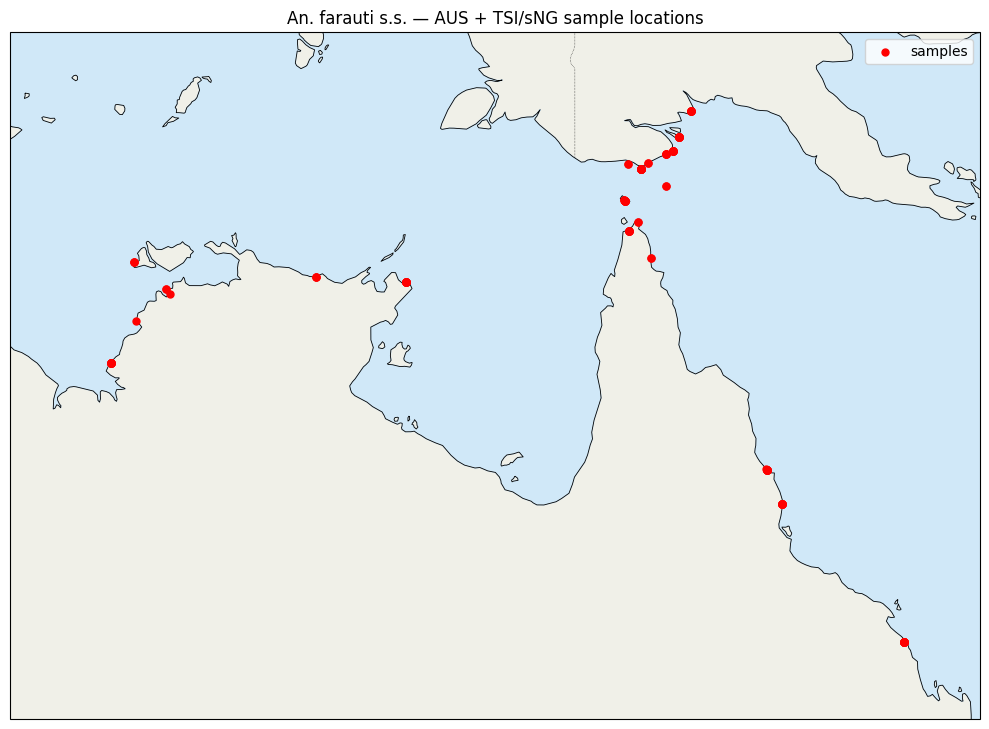

In [6]:
fig, ax = plt.subplots(
    1, 1, figsize=(10, 8), subplot_kw={"projection": ccrs.PlateCarree()}
)
ax.set_extent([127, 151, -23, -6], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color="#f0f0e8", zorder=0)
ax.add_feature(cfeature.OCEAN, color="#d0e8f8", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=":", zorder=1)
ax.scatter(
    coord[:, 0], coord[:, 1],
    transform=ccrs.PlateCarree(),
    s=25, c="red", zorder=5, label="samples"
)
ax.legend()
plt.title("An. farauti s.s. — AUS + TSI/sNG sample locations")
plt.tight_layout()
plt.show()

## 6. Fit FEEMS model

feems v2 defaults to FEEMSmix mode (`optimize_q='n-dim'`), which jointly estimates per-node residual variances and requires `lamb_q` to be set alongside `lamb`. We use `optimize_q=None` here for classic FEEMS (fixed residual variance, only edge weights optimised) — this is equivalent to the original FEEMS paper and simpler to interpret. To run FEEMSmix instead, pass `lamb_q=best_lamb` and remove `optimize_q=None`.

Cross-validation via `run_cv` returns a `(n_folds, n_lamb, n_alpha)` array; we collapse to mean CV error over folds to pick the best lambda.


 fold:  0
iteration lambda=20/20 alpha=1/1
 fold:  1
iteration lambda=20/20 alpha=1/1
 fold:  2
iteration lambda=20/20 alpha=1/1
 fold:  3
iteration lambda=20/20 alpha=1/1
 fold:  4
iteration lambda=20/20 alpha=1/1
 fold:  5
iteration lambda=20/20 alpha=1/1
 fold:  6
iteration lambda=20/20 alpha=1/1
 fold:  7
iteration lambda=20/20 alpha=1/1
 fold:  8
iteration lambda=20/20 alpha=1/1
 fold:  9
iteration lambda=20/20 alpha=1/1

findfont: Font family 'Arial' not found.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


Best lambda: 14.384498882876601


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


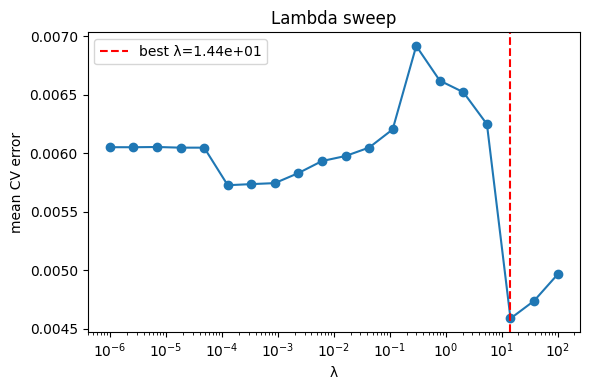

In [7]:
lamb_grid = np.geomspace(1e-6, 1e2, 20)

# run_cv returns (n_folds, n_lamb, n_alpha); collapse to mean over folds and the single alpha
cv_err = run_cv(sp_graph, lamb_grid, n_folds=10, outer_verbose=True)
mean_cv = cv_err.mean(axis=0)[:, 0]

best_lamb = lamb_grid[np.argmin(mean_cv)]
print("Best lambda:", best_lamb)

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogx(lamb_grid, mean_cv, "o-")
ax.axvline(best_lamb, color="red", linestyle="--", label=f"best λ={best_lamb:.2e}")
ax.set_xlabel("λ")
ax.set_ylabel("mean CV error")
ax.legend()
ax.set_title("Lambda sweep")
plt.tight_layout()
plt.show()

In [8]:
sp_graph.fit(lamb=best_lamb, optimize_q=None)

## 7. Visualise effective migration surface

/scratch/temp/24103467/ipykernel_1491349/311423436.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


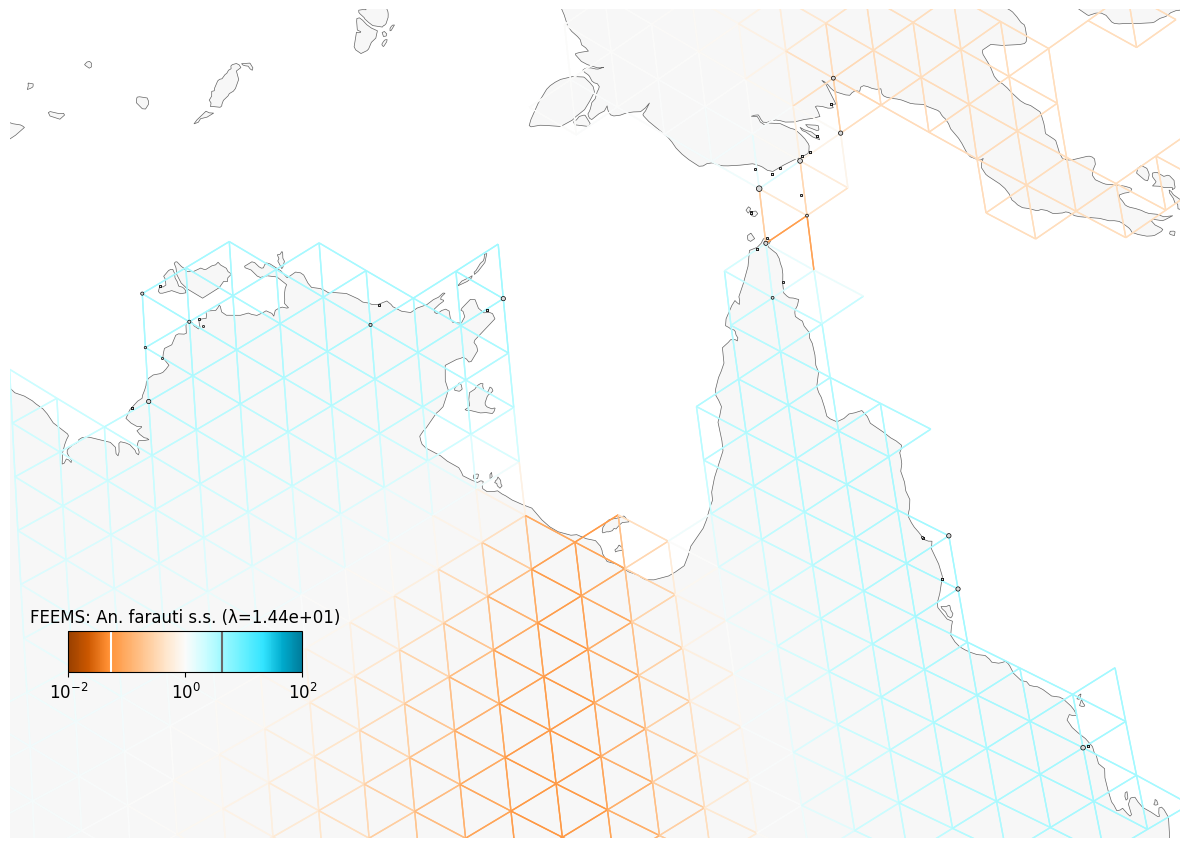

In [9]:
fig, ax = plt.subplots(
    1, 1, figsize=(12, 9), subplot_kw={"projection": ccrs.PlateCarree()}
)
ax.set_extent([127, 151, -23, -6], crs=ccrs.PlateCarree())

viz = Viz(
    ax, sp_graph,
    edge_width=1.0,
    edge_alpha=1.0,
    edge_zorder=100,
    sample_pt_size=10,
    obs_node_size=3,
    sample_pt_zorder=200,
    obs_node_zorder=200,
    coastline_m="50m",
)

viz.draw_map()
viz.draw_edges(use_weights=True)
viz.draw_obs_nodes(use_ids=False)
viz.draw_samples()
viz.draw_edge_colorbar()

plt.title(f"FEEMS: An. farauti s.s. (λ={best_lamb:.2e})")
plt.tight_layout()
plt.savefig("../data/feems_farauti_ss_migration_surface.pdf", dpi=150, bbox_inches="tight")
plt.show()